In [15]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости результатов
np.random.seed(42)

## Загрузка и анализ данных

In [16]:
# Загрузка всех файлов с данными
train_df = pd.read_csv('/Users/phil/GitHub/masters_degree_Roshchin_M25-555/ML/сritical_temperature/data/train.csv')
test_df = pd.read_csv('/Users/phil/GitHub/masters_degree_Roshchin_M25-555/ML/сritical_temperature/data/test.csv')
formula_train = pd.read_csv('/Users/phil/GitHub/masters_degree_Roshchin_M25-555/ML/сritical_temperature/data/formula_train.csv')
formula_test = pd.read_csv('/Users/phil/GitHub/masters_degree_Roshchin_M25-555/ML/сritical_temperature/data/formula_test.csv')

print("Размеры данных:")
print(f"Тренировочные данные: {train_df.shape}")
print(f"Тестовые данные: {test_df.shape}")
print(f"Химические формулы (train): {formula_train.shape}")
print(f"Химические формулы (test): {formula_test.shape}")

# Объединяем данные с формулами для анализа
train_combined = pd.merge(train_df, formula_train, left_index=True, right_index=True)
test_combined = pd.merge(test_df, formula_test, left_index=True, right_index=True)

print("\nПервые 5 строк тренировочных данных:")
print(train_combined.head())

print("\nИнформация о тренировочных данных:")
print(train_combined.info())

print("\nОписательная статистика целевой переменной:")
print(train_combined['critical_temp_y'].describe())

Размеры данных:
Тренировочные данные: (17010, 82)
Тестовые данные: (4253, 81)
Химические формулы (train): (17010, 88)
Химические формулы (test): (4253, 87)

Первые 5 строк тренировочных данных:
   number_of_elements  mean_atomic_mass  wtd_mean_atomic_mass  \
0                   4         88.944468             57.862692   
1                   5         92.729214             58.518416   
2                   4         88.944468             57.885242   
3                   4         88.944468             57.873967   
4                   4         88.944468             57.840143   

   gmean_atomic_mass  wtd_gmean_atomic_mass  entropy_atomic_mass  \
0          66.361592              36.116612             1.181795   
1          73.132787              36.396602             1.449309   
2          66.361592              36.122509             1.181795   
3          66.361592              36.119560             1.181795   
4          66.361592              36.110716             1.181795   

   wtd

## Исследовательский анализ данных (EDA)

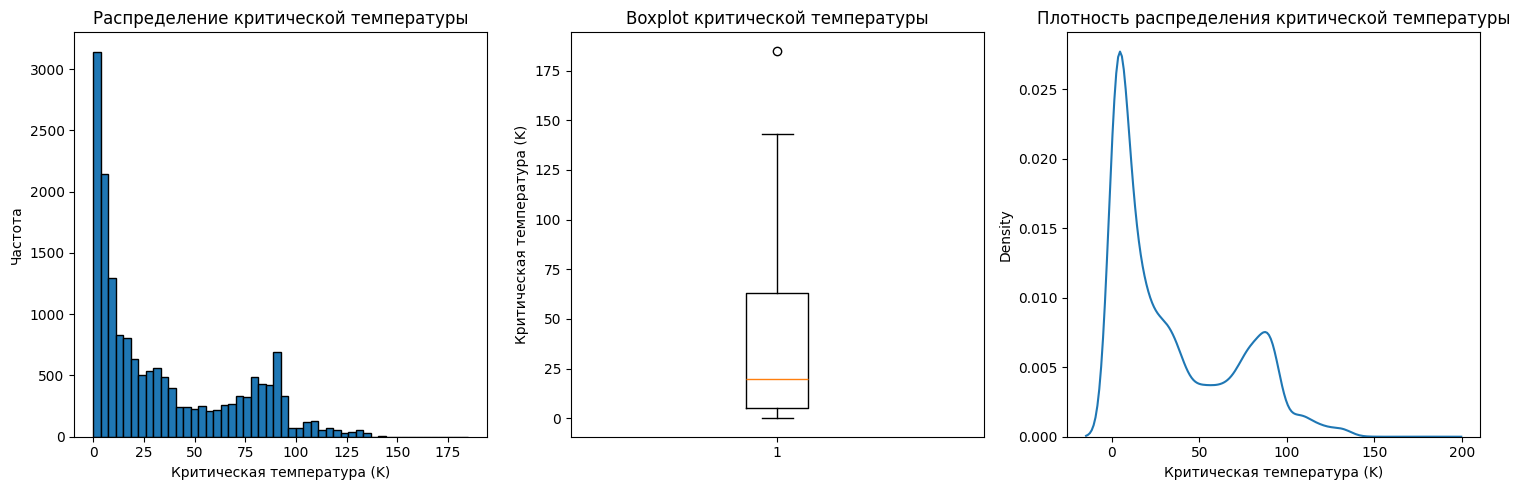


Признаки с пропущенными значениями:
Series([], dtype: int64)


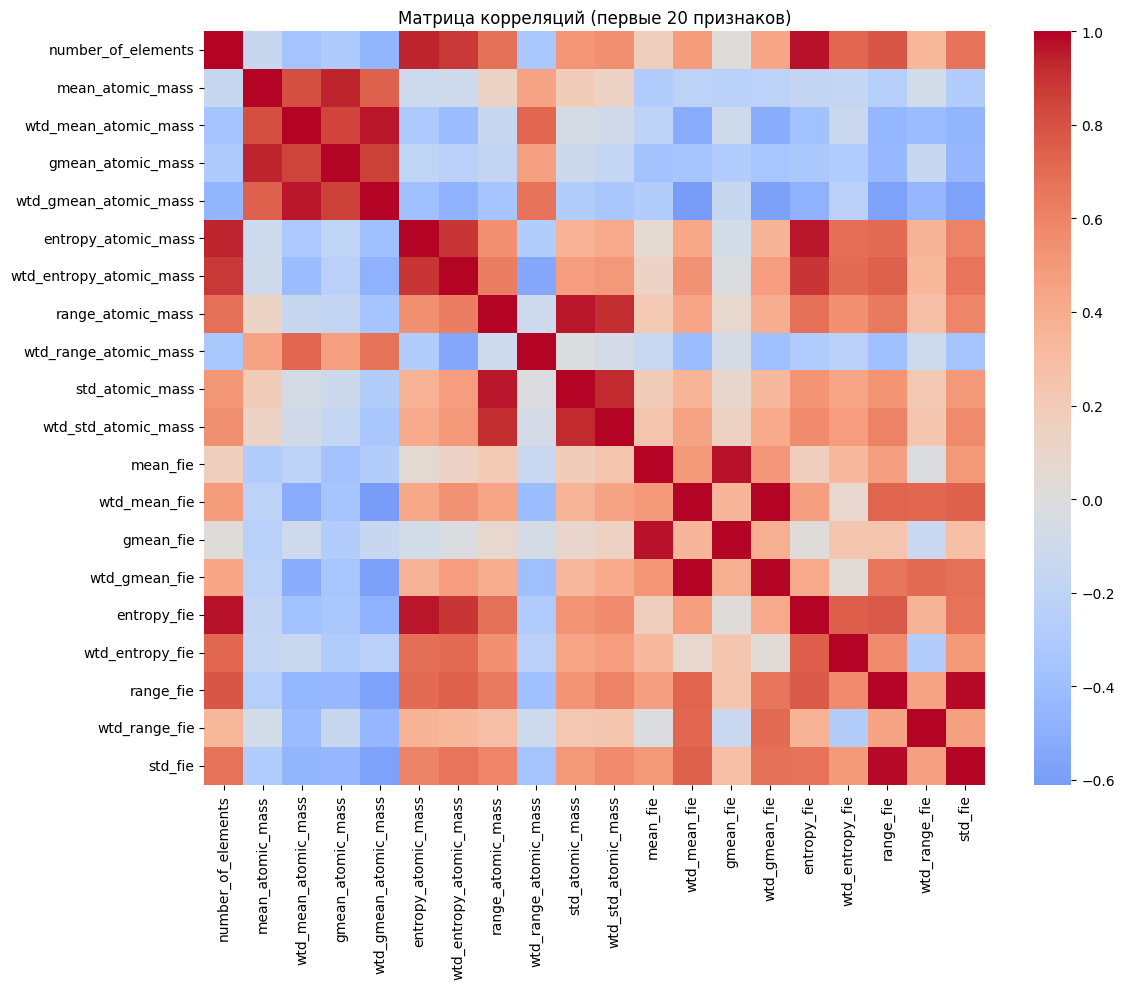

ValueError: could not convert string to float: 'Ba0.2La1.8Cu1O4'

In [17]:
# Анализ целевой переменной
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(train_combined['critical_temp_y'], bins=50, edgecolor='black')
plt.title('Распределение критической температуры')
plt.xlabel('Критическая температура (K)')
plt.ylabel('Частота')

plt.subplot(1, 3, 2)
plt.boxplot(train_combined['critical_temp_y'])
plt.title('Boxplot критической температуры')
plt.ylabel('Критическая температура (K)')

plt.subplot(1, 3, 3)
sns.kdeplot(train_combined['critical_temp_y'])
plt.title('Плотность распределения критической температуры')
plt.xlabel('Критическая температура (K)')

plt.tight_layout()
plt.show()

# Проверка пропущенных значений
missing_values = train_combined.isnull().sum()
print("\nПризнаки с пропущенными значениями:")
print(missing_values[missing_values > 0])

# Анализ корреляции (только для первых 20 признаков для наглядности)
plt.figure(figsize=(12, 10))
correlation_matrix = train_combined.iloc[:, :20].corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Матрица корреляций (первые 20 признаков)')
plt.tight_layout()
plt.show()

# Корреляция с целевой переменной
correlation_with_target = train_combined.corr()['critical_temp_y'].sort_values(ascending=False)
print("\nТоп-10 признаков с наибольшей корреляцией с целевой переменной:")
print(correlation_with_target.head(10))

print("\nТоп-10 признаков с наименьшей корреляцией с целевой переменной:")
print(correlation_with_target.tail(10))

## Предобработка данных

In [ ]:
def preprocess_data(train_df, test_df, formula_train=None, formula_test=None):
    """
    Функция предобработки данных
    """
    # Разделяем признаки и целевую переменную
    X_train = train_df.drop('critical_temp', axis=1)
    y_train = train_df['critical_temp']
    
    X_test = test_df.copy()
    
    # Удаляем ненужные колонки (если есть)
    cols_to_drop = []
    for col in X_train.columns:
        if X_train[col].nunique() == 1:  # Константные признаки
            cols_to_drop.append(col)
    
    X_train = X_train.drop(cols_to_drop, axis=1)
    X_test = X_test.drop(cols_to_drop, axis=1, errors='ignore')
    
    # Обработка пропущенных значений
    for col in X_train.columns:
        if X_train[col].isnull().any():
            # Заполняем медианой
            median_val = X_train[col].median()
            X_train[col] = X_train[col].fillna(median_val)
            X_test[col] = X_test[col].fillna(median_val)
    
    # Обработка выбросов с помощью IQR
    def remove_outliers_iqr(df, column, threshold=1.5):
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR
        return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    
    # Удаляем выбросы только из тренировочных данных
    for col in X_train.columns:
        if X_train[col].dtype in ['float64', 'int64']:
            X_train_clean = remove_outliers_iqr(pd.DataFrame(X_train[col]), col)
            X_train = X_train.loc[X_train_clean.index]
            y_train = y_train.loc[X_train_clean.index]
    
    print(f"После обработки выбросов: X_train.shape = {X_train.shape}, y_train.shape = {y_train.shape}")
    
    # Масштабирование признаков
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, y_train, X_test_scaled, X_train.columns, scaler

# Предобработка данных
X_train_scaled, y_train, X_test_scaled, feature_names, scaler = preprocess_data(
    train_df, test_df, formula_train, formula_test
)

После обработки выбросов: X_train.shape = (520, 81), y_train.shape = (520,)


## Feature Engineering и отбор признаков

Размерность после полиномиальных признаков: (520, 3321)


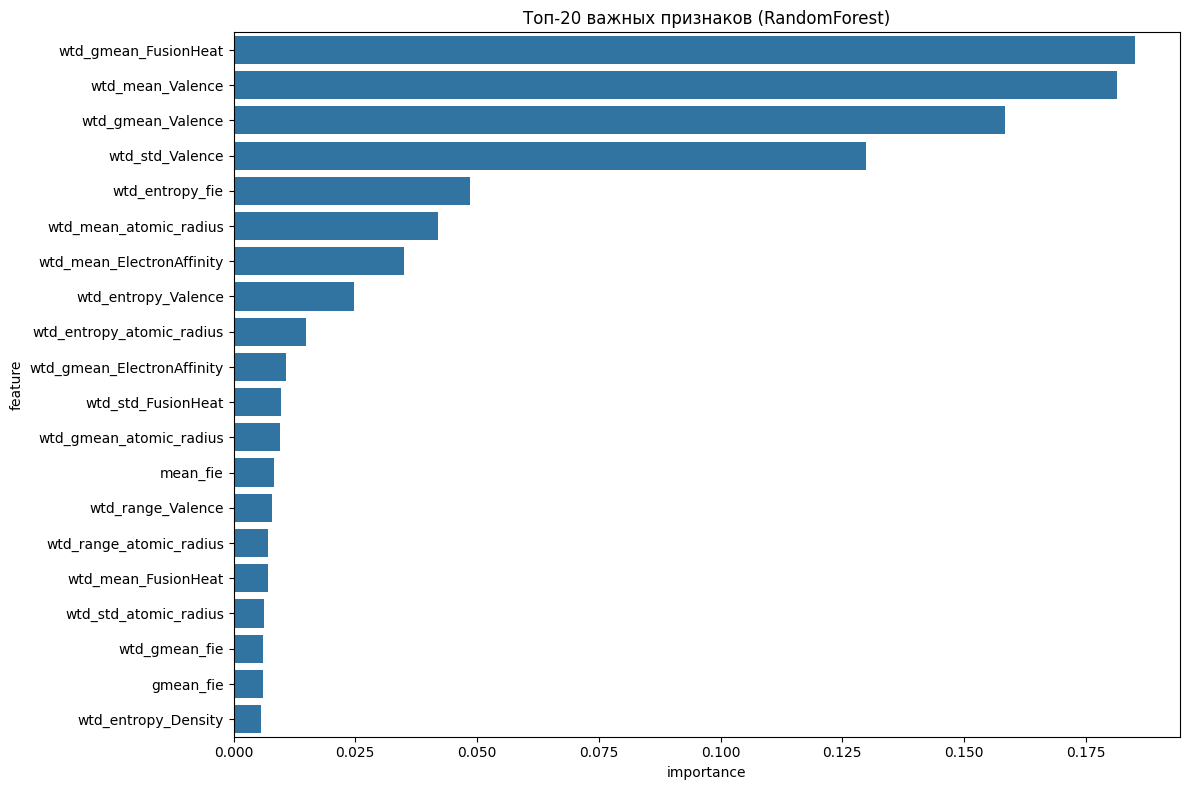


Отобрано 50 наиболее важных признаков
Размерность после отбора признаков: (520, 50)


In [ ]:
def feature_engineering_and_selection(X_train, y_train, X_test, feature_names):
    """
    Создание новых признаков и отбор наиболее важных
    """
    # Создание полиномиальных признаков (второй степени)
    poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    print(f"Размерность после полиномиальных признаков: {X_train_poly.shape}")
    
    # Отбор признаков с помощью RandomForest
    rf_selector = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_selector.fit(X_train, y_train)
    
    # Важность признаков
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': rf_selector.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Визуализация важности признаков
    plt.figure(figsize=(12, 8))
    top_n = min(20, len(feature_importance))
    sns.barplot(data=feature_importance.head(top_n), x='importance', y='feature')
    plt.title(f'Топ-{top_n} важных признаков (RandomForest)')
    plt.tight_layout()
    plt.show()
    
    # Выбор топ-N признаков
    top_features_n = 50  # Можно настроить
    selected_features_idx = feature_importance.head(top_features_n).index
    selected_features = feature_names[selected_features_idx]
    
    print(f"\nОтобрано {top_features_n} наиболее важных признаков")
    
    return X_train[:, selected_features_idx], X_test[:, selected_features_idx], selected_features

# Применение feature engineering и отбора признаков
X_train_selected, X_test_selected, selected_features = feature_engineering_and_selection(
    X_train_scaled, y_train, X_test_scaled, np.array(feature_names)
)

print(f"Размерность после отбора признаков: {X_train_selected.shape}")

## Обучение и сравнение нескольких моделей


Linear Regression:
  CV MSE: 10979.5063 ± 9118.8413
  CV MAE: 17.0279 ± 8.9258
  CV R²:  -113.0909 ± 117.9776

Ridge Regression:
  CV MSE: 90.1475 ± 52.5034
  CV MAE: 6.2196 ± 1.1724
  CV R²:  0.4698 ± 0.1618

Lasso Regression:
  CV MSE: 95.6845 ± 55.3256
  CV MAE: 6.4427 ± 1.4636
  CV R²:  0.4488 ± 0.1711

ElasticNet:
  CV MSE: 99.6536 ± 56.9379
  CV MAE: 6.6204 ± 1.5088
  CV R²:  0.4218 ± 0.1880

Random Forest:
  CV MSE: 86.4532 ± 35.0128
  CV MAE: 5.7559 ± 0.7473
  CV R²:  0.3281 ± 0.5415

Gradient Boosting:
  CV MSE: 86.0228 ± 34.8245
  CV MAE: 5.5792 ± 0.7856
  CV R²:  0.3220 ± 0.5710


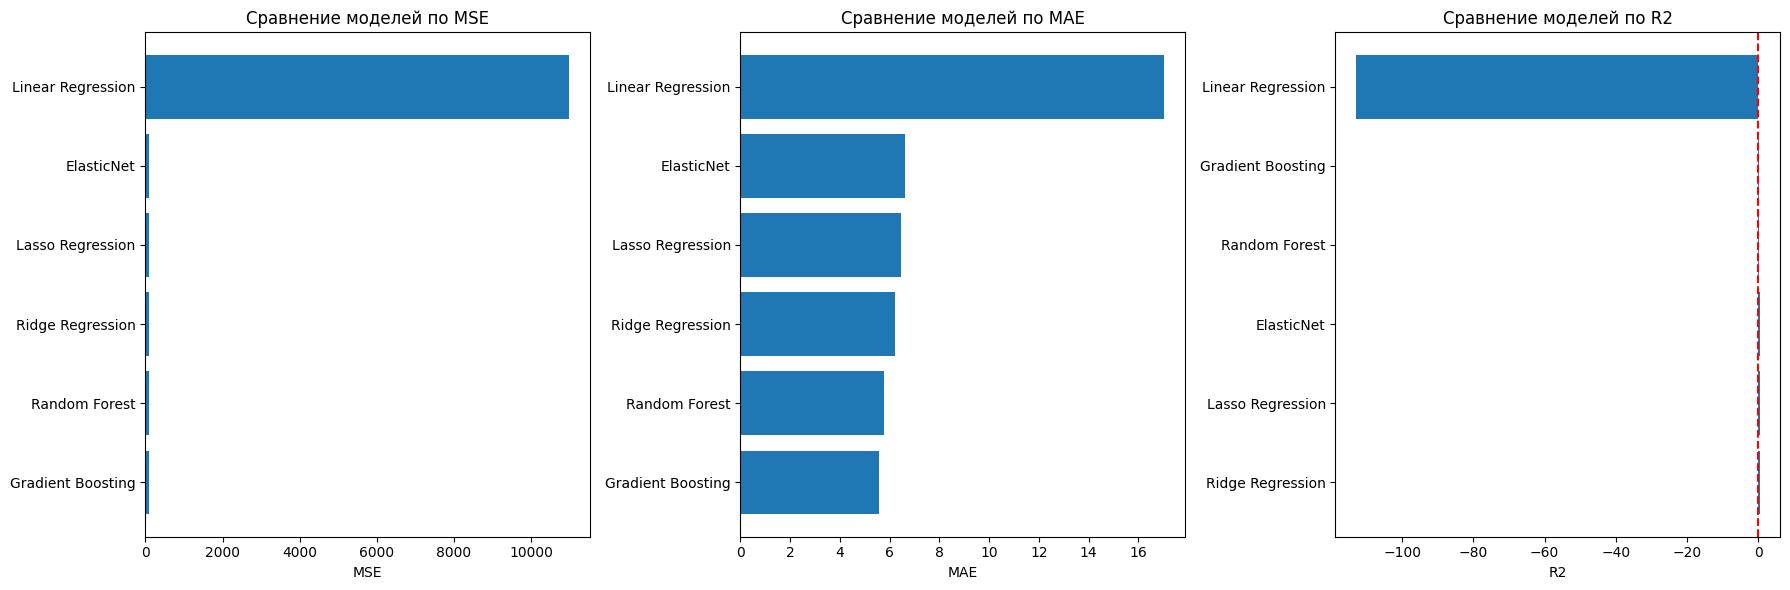

In [ ]:
def evaluate_models(X_train, y_train, cv_folds=5):
    """
    Оценка различных моделей регрессии
    """
    models = {
        'Linear Regression': LinearRegression(),
        'Ridge Regression': Ridge(alpha=1.0),
        'Lasso Regression': Lasso(alpha=0.1),
        'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
    }
    
    results = {}
    
    for name, model in models.items():
        # Кросс-валидация
        cv_scores_mse = -cross_val_score(model, X_train, y_train, 
                                        cv=cv_folds, 
                                        scoring='neg_mean_squared_error')
        cv_scores_mae = -cross_val_score(model, X_train, y_train,
                                        cv=cv_folds,
                                        scoring='neg_mean_absolute_error')
        cv_scores_r2 = cross_val_score(model, X_train, y_train,
                                      cv=cv_folds,
                                      scoring='r2')
        
        # Обучение на всей тренировочной выборке для сравнения
        model.fit(X_train, y_train)
        
        results[name] = {
            'model': model,
            'cv_mse_mean': cv_scores_mse.mean(),
            'cv_mse_std': cv_scores_mse.std(),
            'cv_mae_mean': cv_scores_mae.mean(),
            'cv_mae_std': cv_scores_mae.std(),
            'cv_r2_mean': cv_scores_r2.mean(),
            'cv_r2_std': cv_scores_r2.std()
        }
        
        print(f"\n{name}:")
        print(f"  CV MSE: {cv_scores_mse.mean():.4f} ± {cv_scores_mse.std():.4f}")
        print(f"  CV MAE: {cv_scores_mae.mean():.4f} ± {cv_scores_mae.std():.4f}")
        print(f"  CV R²:  {cv_scores_r2.mean():.4f} ± {cv_scores_r2.std():.4f}")
    
    # Сравнение моделей
    comparison_df = pd.DataFrame({
        'Model': list(results.keys()),
        'MSE': [results[m]['cv_mse_mean'] for m in results],
        'MAE': [results[m]['cv_mae_mean'] for m in results],
        'R2': [results[m]['cv_r2_mean'] for m in results]
    })
    
    # Визуализация сравнения
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    metrics = ['MSE', 'MAE', 'R2']
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        sorted_df = comparison_df.sort_values(metric, ascending=(metric != 'R2'))
        ax.barh(sorted_df['Model'], sorted_df[metric])
        ax.set_xlabel(metric)
        ax.set_title(f'Сравнение моделей по {metric}')
        if metric == 'R2':
            ax.axvline(x=0, color='r', linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    return results, comparison_df

# Оценка моделей
results, comparison_df = evaluate_models(X_train_selected, y_train, cv_folds=5)

## Подбор гиперпараметров для лучшей модели

In [ ]:
def hyperparameter_tuning(X_train, y_train, model_name, model, param_grid):
    """
    Подбор гиперпараметров с помощью GridSearchCV
    """
    print(f"\nПодбор гиперпараметров для {model_name}")
    
    # Используем KFold для кросс-валидации
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=kf,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    print(f"Лучшие параметры: {grid_search.best_params_}")
    print(f"Лучший MSE: {-grid_search.best_score_:.4f}")
    
    return grid_search.best_estimator_

# Выбор лучшей модели по MSE
best_model_name = comparison_df.loc[comparison_df['MSE'].idxmin(), 'Model']
print(f"\nЛучшая модель по MSE: {best_model_name}")

# Подбор гиперпараметров в зависимости от модели
best_model = results[best_model_name]['model']

if best_model_name == 'Ridge Regression':
    param_grid = {
        'alpha': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']
    }
    
elif best_model_name == 'Lasso Regression':
    param_grid = {
        'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10],
        'max_iter': [1000, 5000, 10000]
    }
    
elif best_model_name == 'ElasticNet':
    param_grid = {
        'alpha': [0.0001, 0.001, 0.01, 0.1, 1],
        'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
        'max_iter': [1000, 5000]
    }
    
elif best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    
elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'min_samples_split': [2, 5, 10]
    }
    
else:  # Linear Regression
    param_grid = {}  # Линейная регрессия не имеет гиперпараметров для настройки

if param_grid:  # Если есть параметры для настройки
    tuned_model = hyperparameter_tuning(X_train_selected, y_train, best_model_name, 
                                       type(best_model)(), param_grid)
else:
    tuned_model = best_model
    print("Для Linear Regression нет гиперпараметров для настройки")


Лучшая модель по MSE: Gradient Boosting

Подбор гиперпараметров для Gradient Boosting
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 100}
Лучший MSE: 69.9496


## Оценка финальной модели

Результаты на тренировочной выборке:
MSE: 41.5431
RMSE: 6.4454
MAE: 3.8595
R²: 0.8114


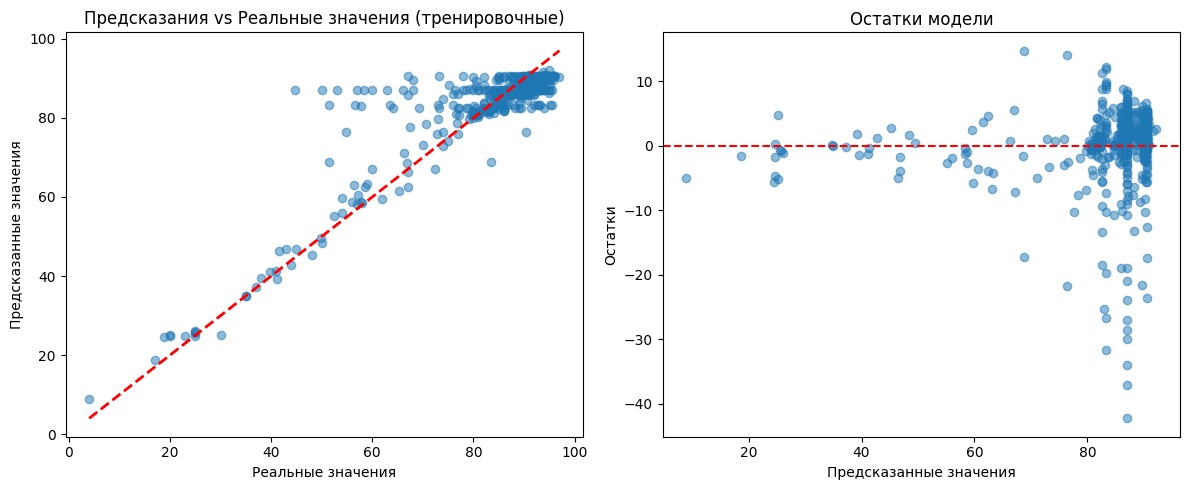

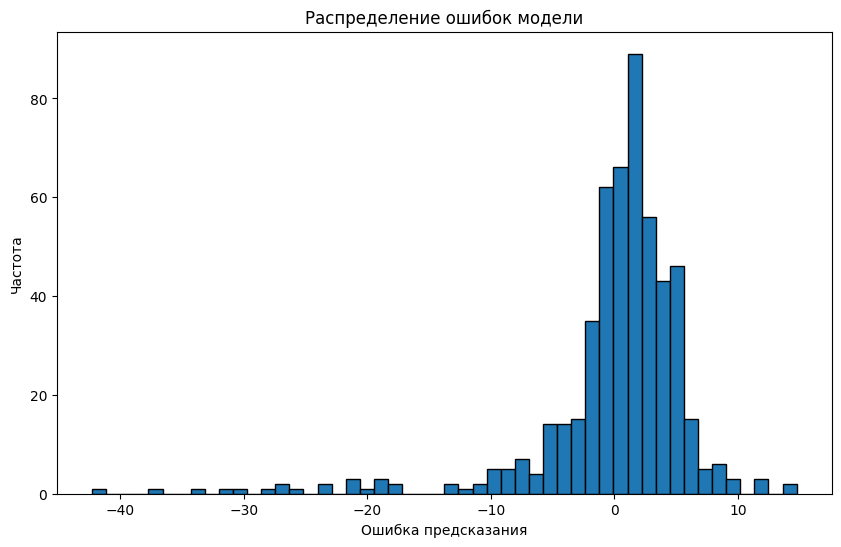

In [ ]:
def evaluate_final_model(model, X_train, y_train, X_test=None, y_test=None):
    """
    Детальная оценка финальной модели
    """
    # Обучение на всей тренировочной выборке
    model.fit(X_train, y_train)
    
    # Предсказания на тренировочной выборке
    y_train_pred = model.predict(X_train)
    
    print("Результаты на тренировочной выборке:")
    print(f"MSE: {mean_squared_error(y_train, y_train_pred):.4f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}")
    print(f"MAE: {mean_absolute_error(y_train, y_train_pred):.4f}")
    print(f"R²: {r2_score(y_train, y_train_pred):.4f}")
    
    # Визуализация предсказаний vs реальные значения
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.scatter(y_train, y_train_pred, alpha=0.5)
    plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
    plt.xlabel('Реальные значения')
    plt.ylabel('Предсказанные значения')
    plt.title('Предсказания vs Реальные значения (тренировочные)')
    
    plt.subplot(1, 2, 2)
    residuals = y_train - y_train_pred
    plt.scatter(y_train_pred, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Предсказанные значения')
    plt.ylabel('Остатки')
    plt.title('Остатки модели')
    
    plt.tight_layout()
    plt.show()
    
    # Распределение ошибок
    plt.figure(figsize=(10, 6))
    plt.hist(residuals, bins=50, edgecolor='black')
    plt.xlabel('Ошибка предсказания')
    plt.ylabel('Частота')
    plt.title('Распределение ошибок модели')
    plt.show()
    
    return model

# Оценка финальной модели
final_model = evaluate_final_model(tuned_model, X_train_selected, y_train)

## Предсказание на тестовых данных и создание submission файла

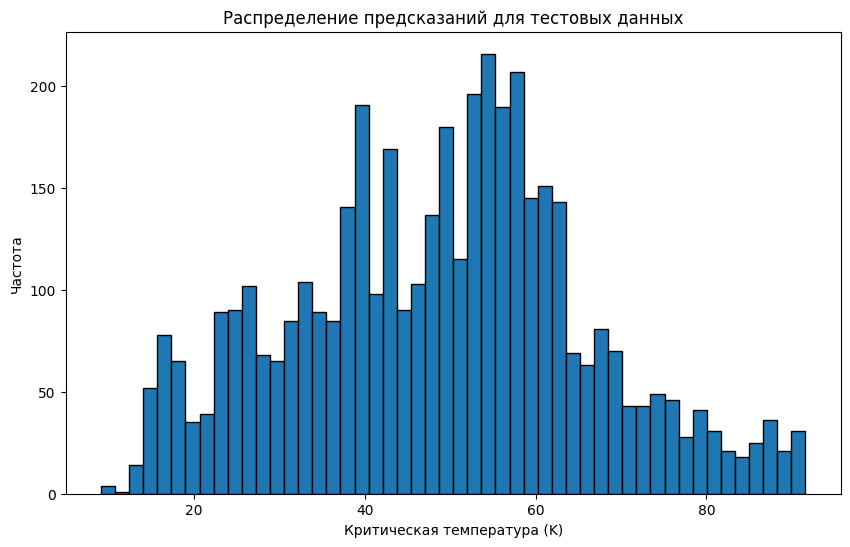


Файл submission.csv сохранен
Размер submission файла: (4253, 2)
Пример предсказаний:
   index  critical_temp
0      0      49.896274
1      1      57.228313
2      2      40.165777
3      3      38.041031
4      4      39.560843
5      5      89.825979
6      6      52.743947
7      7      57.052403
8      8      54.457884
9      9      37.857802


In [ ]:
# Предсказание на тестовых данных
test_predictions = final_model.predict(X_test_selected)

# Проверка распределения предсказаний
plt.figure(figsize=(10, 6))
plt.hist(test_predictions, bins=50, edgecolor='black')
plt.title('Распределение предсказаний для тестовых данных')
plt.xlabel('Критическая температура (K)')
plt.ylabel('Частота')
plt.show()

# Создание submission файла
submission = pd.DataFrame({
    'index': range(len(test_predictions)),
    'critical_temp': test_predictions
})

# Сохранение результатов
submission.to_csv('/Users/phil/GitHub/masters_degree_Roshchin_M25-555/ML/сritical_temperature/data/submission.csv', index=False)
print("\nФайл submission.csv сохранен")
print(f"Размер submission файла: {submission.shape}")
print(f"Пример предсказаний:\n{submission.head(10)}")

## Анализ важности признаков для интерпретации модели

Топ-20 наиболее важных признаков:
                            feature  importance
3                   wtd_std_Valence    0.263318
1                  wtd_mean_Valence    0.205450
2                 wtd_gmean_Valence    0.202601
5            wtd_mean_atomic_radius    0.060693
4                   wtd_entropy_fie    0.051635
7               wtd_entropy_Valence    0.022789
6         wtd_mean_ElectronAffinity    0.020267
22           wtd_entropy_FusionHeat    0.012224
27                  entropy_Density    0.011786
9        wtd_gmean_ElectronAffinity    0.011456
10               wtd_std_FusionHeat    0.010924
11          wtd_gmean_atomic_radius    0.010106
8         wtd_entropy_atomic_radius    0.009393
15              wtd_mean_FusionHeat    0.008330
28  wtd_entropy_ThermalConductivity    0.007333
19              wtd_entropy_Density    0.006997
16            wtd_std_atomic_radius    0.006466
40                     wtd_mean_fie    0.005625
17                    wtd_gmean_fie    0.005358
26    

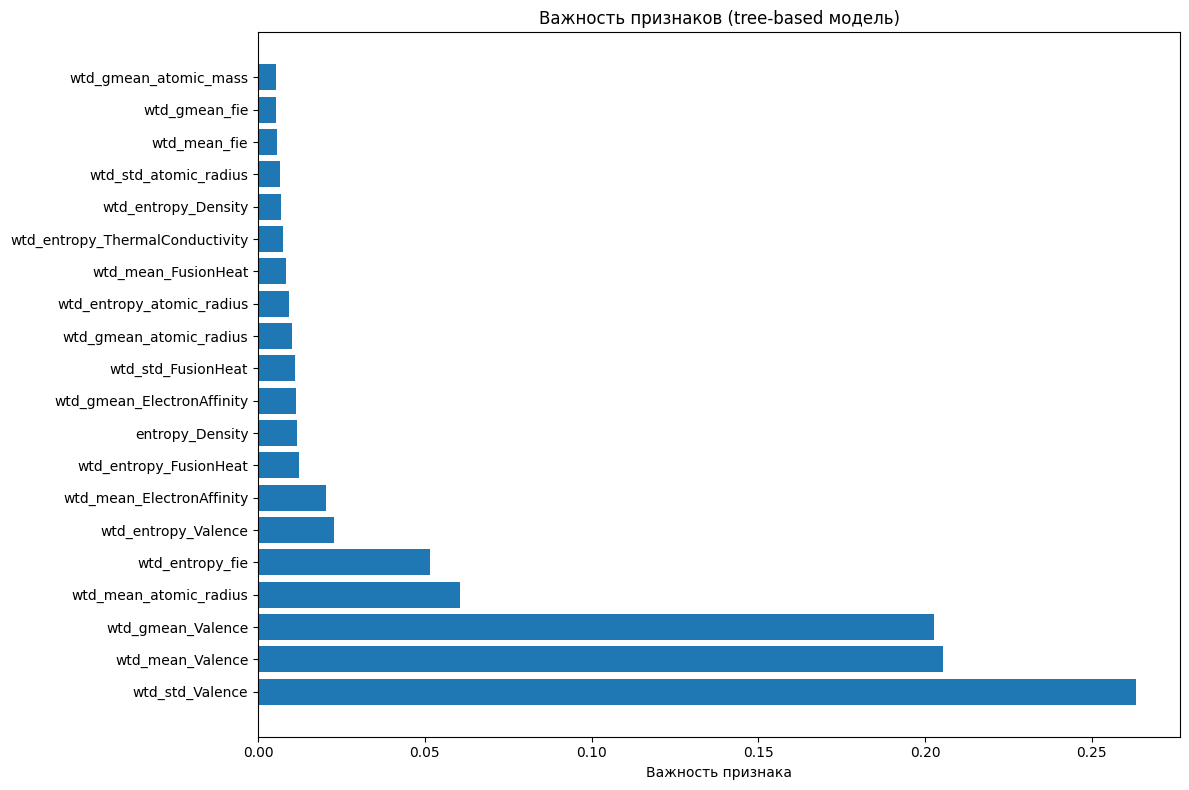

In [18]:
def analyze_feature_importance(model, feature_names):
    """
    Анализ важности признаков для интерпретации модели
    """
    if hasattr(model, 'coef_'):  # Для линейных моделей
        importance = pd.DataFrame({
            'feature': feature_names,
            'coefficient': model.coef_,
            'abs_coefficient': np.abs(model.coef_)
        }).sort_values('abs_coefficient', ascending=False)
        
        print("Топ-20 наиболее важных признаков (по абсолютным коэффициентам):")
        print(importance.head(20))
        
        # Визуализация коэффициентов
        plt.figure(figsize=(12, 8))
        top_n = min(20, len(importance))
        colors = ['red' if coef < 0 else 'blue' for coef in importance['coefficient'].head(top_n)]
        plt.barh(range(top_n), importance['coefficient'].head(top_n), color=colors)
        plt.yticks(range(top_n), importance['feature'].head(top_n))
        plt.xlabel('Коэффициент')
        plt.title('Важность признаков (коэффициенты линейной модели)')
        plt.axvline(x=0, color='black', linestyle='-')
        plt.tight_layout()
        plt.show()
        
    elif hasattr(model, 'feature_importances_'):  # Для tree-based моделей
        importance = pd.DataFrame({
            'feature': feature_names,
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        print("Топ-20 наиболее важных признаков:")
        print(importance.head(20))
        
        # Визуализация важности признаков
        plt.figure(figsize=(12, 8))
        top_n = min(20, len(importance))
        plt.barh(range(top_n), importance['importance'].head(top_n))
        plt.yticks(range(top_n), importance['feature'].head(top_n))
        plt.xlabel('Важность признака')
        plt.title('Важность признаков (tree-based модель)')
        plt.tight_layout()
        plt.show()
    
    return importance

# Анализ важности признаков
if hasattr(final_model, 'coef_') or hasattr(final_model, 'feature_importances_'):
    feature_importance_df = analyze_feature_importance(final_model, selected_features)

## Kaggle

[Submittion - click here](https://github.com/PHILIPP111007/masters_degree_Roshchin_M25-555/blob/main/ML/сritical_temperature/data/result.png)